<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/DeepLearning/DeepLearning_batch_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
df = pd.read_csv('/ai_human_content_detection_dataset.csv')

df.head()

,text_content,content_type,word_count,character_count,sentence_count,lexical_diversity,avg_sentence_length,avg_word_length,punctuation_ratio,flesch_reading_ease,gunning_fog_index,grammar_errors,passive_voice_ratio,predictability_score,burstiness,sentiment_score,label
0,Score each cause. Quality throughout beautiful...,academic_paper,288,1927,54,0.9514,5.33,5.69,0.0280,53.08,7.41,1,0.1041,105.86,0.5531,0.2034,1
1,Board its rock. Job worker break tonight coupl...,essay,253,1719,45,0.9723,5.62,5.80,0.0262,50.32,8.10,6,0.2045,100.29,0.5643,0.4854,1
2,Way debate decision produce. Dream necessary c...,academic_paper,420,2849,75,0.9071,5.60,5.79,0.0263,46.86,7.86,5,0.2308,96.88,0.4979,-0.2369,1
3,Story turn because such during open model. Tha...,creative_writing,196,1310,34,0.9592,5.76,5.69,0.0260,53.80,7.00,2,0.1912,88.79,0.6241,NaN,1
4,Place specific as simply leader fall analysis....,news_article,160,1115,28,0.9688,5.71,5.97,0.0251,44.53,8.29,0,0.1318,26.15,0.2894,NaN,1


In [ ]:
df.label.value_counts()

,count
label,
0,684
1,683


In [ ]:
texts = df.text_content.values
labels = df.label.values

In [ ]:
labels.dtype

dtype('int64')

In [ ]:
type(labels)

numpy.ndarray

In [ ]:
type(texts)

numpy.ndarray

In [ ]:
texts.shape

(1367,)

In [ ]:
labels.shape

(1367,)

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)


In [ ]:
np.unique(labels)

array([0, 1])

In [ ]:
MAX_WORDS = 10000  # Maximum number of words to keep
MAX_LENGTH = 200    # Maximum length of sequences


# Create and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='')
tokenizer.fit_on_texts(X_train_text)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"\nVocabulary size: {len(tokenizer.word_index)}")
print(f"Padded sequence shape: {X_train_padded.shape}")


# Show example of tokenization
example_text = X_train_text[0][:100]
example_seq = tokenizer.texts_to_sequences([example_text])[0]
print(f"\nExample text: '{example_text}...'")
print(f"Tokenized: {example_seq[:10]}...")


Vocabulary size: 972
Padded sequence shape: (1093, 200)

Example text: 'Listen information scene again. As the discussion water popular. Official pretty skin main program m...'
Tokenized: [341, 660, 205, 153, 272, 366, 554, 28, 273, 14]...


In [ ]:
def create_basic_model():
    """
    Create a basic neural network model.
    """
    model = models.Sequential([
        # Embedding layer: converts word indices to dense vectors
        layers.Embedding(input_dim=MAX_WORDS,
                        output_dim=128,
                        input_length=MAX_LENGTH),

        # Flatten the 2D embedding to 1D
        layers.Flatten(),

        # Hidden layer with ReLU activation
        layers.Dense(64, activation='relu'),

        # Output layer with sigmoid for binary classification
        layers.Dense(1, activation='sigmoid')


    ])


    model.build(input_shape=(None, MAX_LENGTH))
    return model

# Create and compile the model
basic_model = create_basic_model()

basic_model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Basic Model Architecture:")
basic_model.summary()

Basic Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,918,529 (11.13 MB)

 Trainable params: 2,918,529 (11.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the basic model
print("Training Basic Model...")
print("="*50)

history_basic = basic_model.fit(
    X_train_padded, y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=1
)



Training Basic Model...
Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.5092 - loss: 0.6928 - val_accuracy: 0.4749 - val_loss: 0.6928
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5263 - loss: 0.6915 - val_accuracy: 0.4703 - val_loss: 0.6934
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5343 - loss: 0.6903 - val_accuracy: 0.4612 - val_loss: 0.6938
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5423 - loss: 0.6891 - val_accuracy: 0.4612 - val_loss: 0.6940
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5503 - loss: 0.6879 - val_accuracy: 0.4612 - val_loss: 0.6942
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5572 - loss: 0.6867 - val_accuracy: 0.4612 - val_loss: 0.6943
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5698 - loss: 0.6855 - val_accuracy: 0.4658 - val_loss: 0.6944
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5778 - loss: 0.6843 - 

In [ ]:
(basic_model.predict(X_test_padded) > 0.5).astype(int).flatten()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


array([0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
# Evaluate the model
print("\nEvaluating Basic Model...")
basic_predictions = (basic_model.predict(X_test_padded) > 0.5).astype(int).flatten()
basic_accuracy = accuracy_score(y_test, basic_predictions)

print(f"\n{'='*50}")
print(f"Basic Model Test Accuracy: {basic_accuracy:.4f}")
print(f"{'='*50}")




Evaluating Basic Model...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Basic Model Test Accuracy: 0.4891


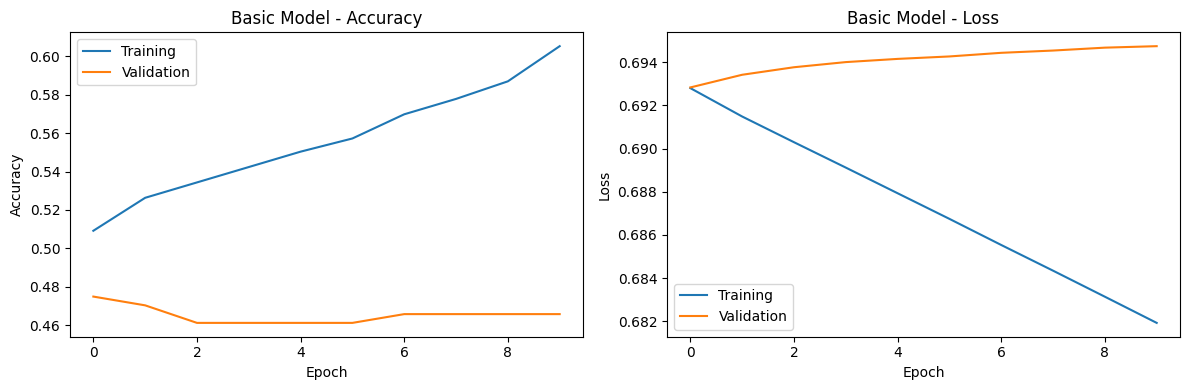

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_basic.history['accuracy'], label='Training')
plt.plot(history_basic.history['val_accuracy'], label='Validation')
plt.title('Basic Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_basic.history['loss'], label='Training')
plt.plot(history_basic.history['val_loss'], label='Validation')
plt.title('Basic Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

def create_dropout_model():
    """
    Create a neural network with dropout layers.
    """
    model = models.Sequential([
        # Embedding layer
        layers.Embedding(input_dim=MAX_WORDS,
                        output_dim=128,
                        input_length=MAX_LENGTH),

        # Global Average Pooling (better than Flatten for text)
        layers.GlobalAveragePooling1D(),

        # First hidden layer
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),  # Drop 50% of connections randomly

        # Second hidden layer
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),  # Drop 30% of connections randomly

        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])
    model.build(input_shape=(None, MAX_LENGTH))
    return model

# Create and compile the dropout model
dropout_model = create_dropout_model()

dropout_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Dropout Model Architecture:")
dropout_model.summary()


Dropout Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,304,833 (4.98 MB)

 Trainable params: 1,304,833 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training Dropout Model...")
print("="*50)

history_dropout = dropout_model.fit(
    X_train_padded, y_train,
    batch_size=32,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate dropout model
print("\nEvaluating Dropout Model...")
dropout_predictions = (dropout_model.predict(X_test_padded) > 0.5).astype(int).flatten()
dropout_accuracy = accuracy_score(y_test, dropout_predictions)

print(f"\n{'='*50}")
print(f"Dropout Model Test Accuracy: {dropout_accuracy:.4f}")
print(f"{'='*50}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, dropout_predictions,
                          target_names=['Human', 'AI']))

Training Dropout Model...
Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.4783 - loss: 0.6958 - val_accuracy: 0.4338 - val_loss: 0.6938
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5103 - loss: 0.6931 - val_accuracy: 0.4658 - val_loss: 0.6952
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5080 - loss: 0.6941 - val_accuracy: 0.4703 - val_loss: 0.6956
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5481 - loss: 0.6916 - val_accuracy: 0.4566 - val_loss: 0.6982

Evaluating Dropout Model...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step

Dropout Model Test Accuracy: 0.5073

Classification Report:
              precision    recall  f1-score   support

       Human       0.50      0.96      0.66       137
          AI       0.58      0.05      0.09       137

    accuracy                           0.51       274
   macro avg       0.54      0.51      0.38       274
weighted avg       0.54      0.51      0.38       274



In [ ]:
def create_batchnorm_model():
    """
    Create a neural network with batch normalization.
    """
    model = models.Sequential([
        # Embedding layer
        layers.Embedding(input_dim=MAX_WORDS,
                        output_dim=128,
                        input_length=MAX_LENGTH),

        # Use Global Average Pooling instead of LSTM for now
        layers.GlobalAveragePooling1D(),

        # First dense block with batch normalization
        layers.Dense(128),
        layers.BatchNormalization(),  # Normalize before activation
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Second dense block with batch normalization
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])

    # Build the model
    model.build(input_shape=(None, MAX_LENGTH))

    return model

# Create and compile the batch norm model
batchnorm_model = create_batchnorm_model()

batchnorm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Batch Normalization Model Architecture:")
batchnorm_model.summary()

Batch Normalization Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,305,601 (4.98 MB)

 Trainable params: 1,305,217 (4.98 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
print("Training Batch Normalization Model...")
print("="*50)
print("Note: This model uses LSTM, so training might be slower")

history_batchnorm = batchnorm_model.fit(
    X_train_padded, y_train,
    batch_size=32,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate batch norm model
print("\nEvaluating Batch Normalization Model...")
batchnorm_predictions = (batchnorm_model.predict(X_test_padded) > 0.5).astype(int).flatten()
batchnorm_accuracy = accuracy_score(y_test, batchnorm_predictions)

print(f"\n{'='*50}")
print(f"Batch Norm Model Test Accuracy: {batchnorm_accuracy:.4f}")
print(f"{'='*50}")

Training Batch Normalization Model...
Note: This model uses LSTM, so training might be slower
Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.4565 - loss: 0.7842 - val_accuracy: 0.5297 - val_loss: 0.6929
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4908 - loss: 0.7548 - val_accuracy: 0.5297 - val_loss: 0.6922
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5469 - loss: 0.7137 - val_accuracy: 0.5160 - val_loss: 0.6922
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5698 - loss: 0.7037 - val_accuracy: 0.5479 - val_loss: 0.6924
Epoch 5/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6842 - loss: 0.6168 - val_accuracy: 0.5251 - val_loss: 0.6937
Epoch 6/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7494 - loss: 0.5355 - val_accuracy: 0.5023 - val_loss: 0.6953

Evaluating Batch Normalization Model...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step

Batch Norm Model Test Accuracy: 0.5219


In [ ]:
basic_model.count_params()

2918529

In [ ]:
dropout_model.count_params()

1304833

In [ ]:
batchnorm_model.count_params()

1305601

In [ ]:
def predict_text(text, model, tokenizer, max_length=MAX_LENGTH):
    """
    Predict whether a text is AI-generated or human-written.
    """
    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')

    # Make prediction
    prediction = model.predict(padded, verbose=0)[0][0]

    return prediction

print("="*80)
print("TEST WITH CUSTOM TEXTS")
print("="*80)

# Test texts
test_texts = [
    "Hello world",
    "In accordance with the aforementioned parameters, we shall proceed to implement the optimal solution.",
    "Hey! Just wanted to say hi and see how you're doing. Hope everything's good!",
    "The implementation demonstrates superior performance metrics across all evaluated dimensions.",
    "LOL that's so funny! Can't believe that happened 😂"
]

print("\nUsing the Advanced Model for predictions:\n")

for i, text in enumerate(test_texts, 1):
    pred = predict_text(text, batchnorm_model, tokenizer)
    label = "AI-generated" if pred > 0.5 else "Human-written"
    confidence = pred if pred > 0.5 else (1 - pred)

    print(f"Text {i}: '{text[:60]}...'" if len(text) > 60 else f"Text {i}: '{text}'")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2%}")
    print("-" * 40)

TEST WITH CUSTOM TEXTS

Using the Advanced Model for predictions:

Text 1: 'Hello world'
Prediction: Human-written
Confidence: 50.34%
----------------------------------------
Text 2: 'In accordance with the aforementioned parameters, we shall p...'
Prediction: Human-written
Confidence: 50.29%
----------------------------------------
Text 3: 'Hey! Just wanted to say hi and see how you're doing. Hope ev...'
Prediction: Human-written
Confidence: 50.30%
----------------------------------------
Text 4: 'The implementation demonstrates superior performance metrics...'
Prediction: Human-written
Confidence: 50.30%
----------------------------------------
Text 5: 'LOL that's so funny! Can't believe that happened 😂'
Prediction: Human-written
Confidence: 50.31%
----------------------------------------


#Saving a model

In [ ]:
# Save models
print("Saving models...")

# Save in H5 format
basic_model.save('basic_model.h5')
dropout_model.save('dropout_model.h5')
batchnorm_model.save('batchnorm_model.h5')

# Save tokenizer
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("✅ All models saved successfully!")
print("\nTo load a model later:")
print("model = keras.models.load_model('model_name.h5')")
print("\nTo load the tokenizer:")
print("with open('tokenizer.pickle', 'rb') as handle:")
print("    tokenizer = pickle.load(handle)")

Saving models...
✅ All models saved successfully!

To load a model later:
model = keras.models.load_model('model_name.h5')

To load the tokenizer:
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)
